## Problem Identification

##### To predict the Purchased Rate of the car 

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn import tree
%matplotlib inline

### Load Data Sheet

In [3]:
car_data = pd.read_csv('car_data.csv')

In [4]:
car_data

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


## EDA

In [50]:
car_data.shape

(1000, 5)

In [51]:
car_data.size

5000

In [52]:
car_data.columns

Index(['User ID', 'Gender', 'Age', 'AnnualSalary', 'Purchased'], dtype='object')

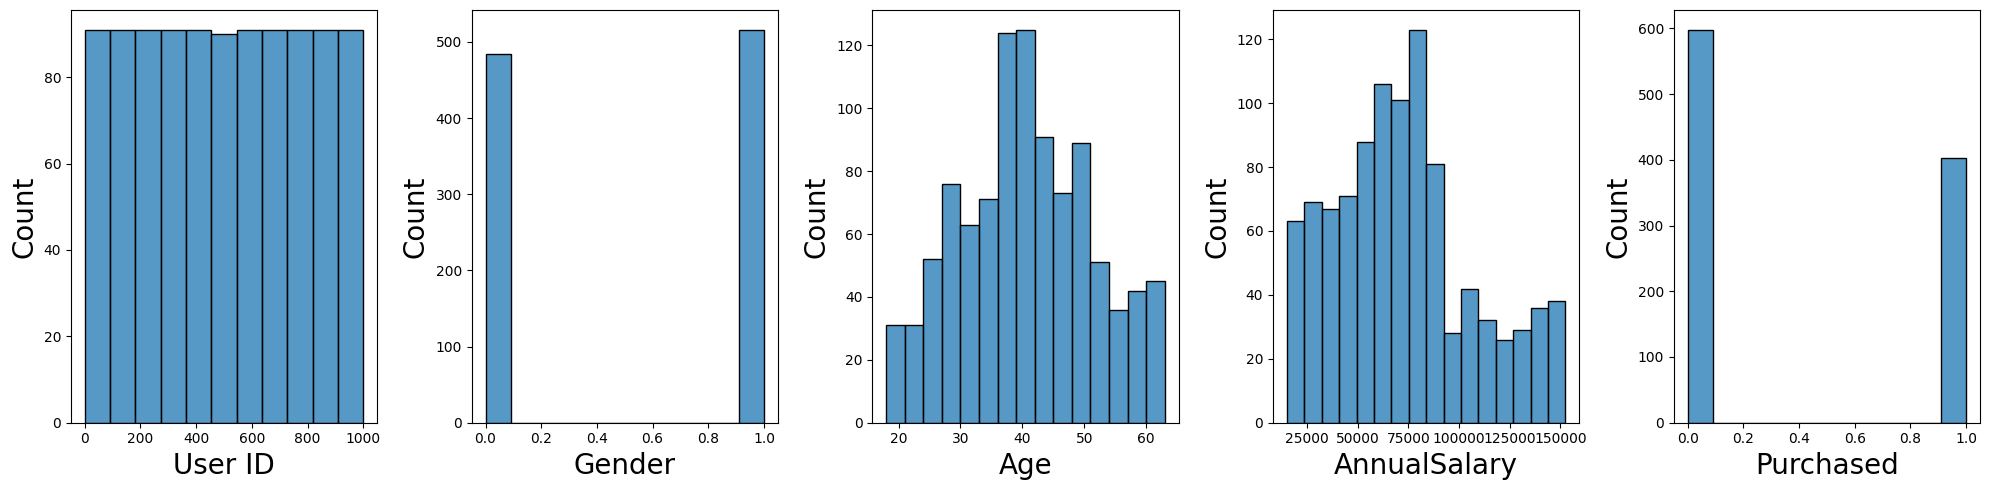

In [62]:
# Uni-variant
plt.figure(figsize=(20,5),facecolor='white')
plotnumber=1

for column in car_data:
    if plotnumber<=5: # 5 columns
        ax=plt.subplot(1,5,plotnumber) # 1 x 5 is refers columns = 5
        sns.histplot(car_data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

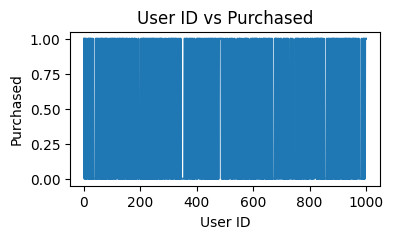

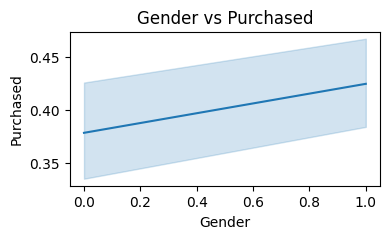

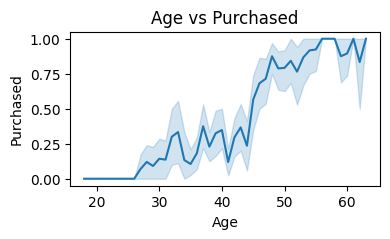

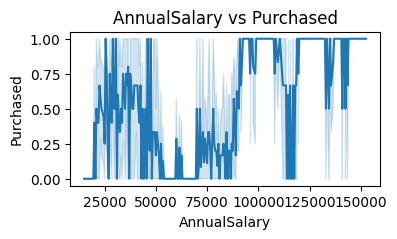

In [66]:
# Bi-Variant
import seaborn as sns
import matplotlib.pyplot as plt


for col in car_data:
    if col != 'Purchased':
        plt.figure(figsize=(4,2))
        sns.lineplot(x=car_data[col], y=car_data['Purchased'])
        plt.title(f"{col} vs Purchased")
        plt.show()

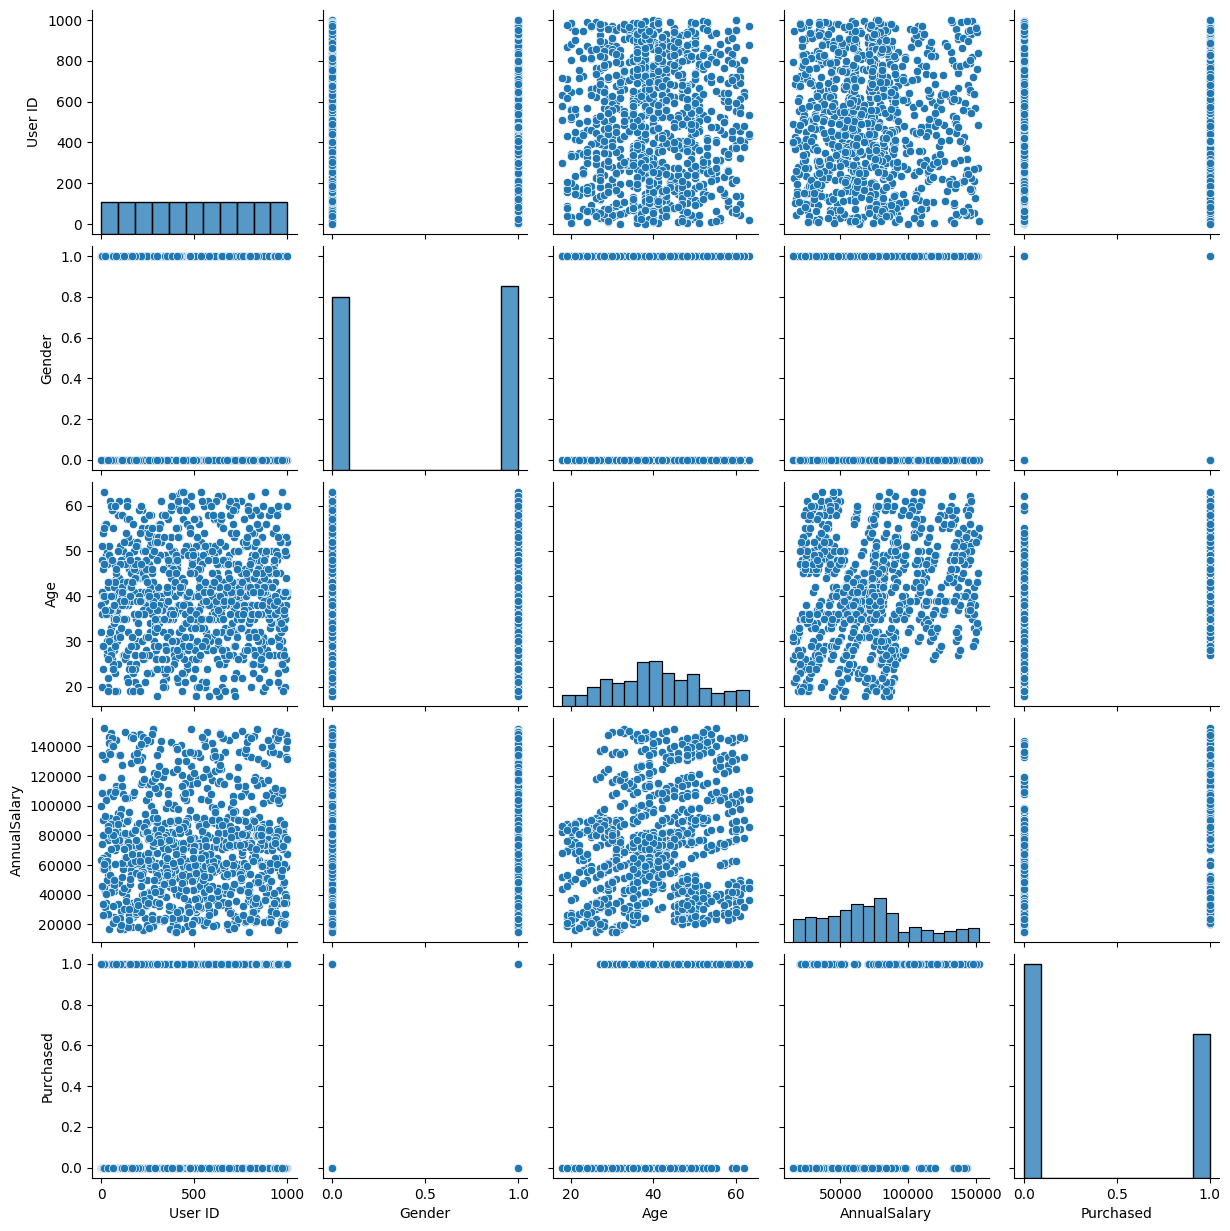

In [68]:
# Multi-Variant
sns.pairplot(car_data)

## Basic Checks

In [5]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [9]:
car_data.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [10]:
car_data.tail()

,User ID,Gender,Age,AnnualSalary,Purchased
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1
999,687,Female,44,73500,0


In [11]:
car_data.describe()

,User ID,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.106000,72689.000000,0.402000
std,288.819436,10.707073,34488.341867,0.490547
min,1.000000,18.000000,15000.000000,0.000000
25%,250.750000,32.000000,46375.000000,0.000000
50%,500.500000,40.000000,72000.000000,0.000000
75%,750.250000,48.000000,90000.000000,1.000000
max,1000.000000,63.000000,152500.000000,1.000000


## Data Preprocessing and Feature Engineering

In [13]:
# Step 1: Check for Missing Values
car_data.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [6]:
# Step 2: Convert Categorical data into Numerical data 
car_data['Gender'] = car_data['Gender'].map({'Male':0, 'Female':1})

In [7]:
car_data.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,0,35,20000,0
1,681,0,40,43500,0
2,353,0,49,74000,0
3,895,0,40,107500,1
4,661,0,25,79000,0


In [8]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   int64
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [17]:
# Step 4: Check if the target variable is balanced or not
car_data.Purchased.value_counts()

Purchased
0    598
1    402
Name: count, dtype: int64

## Model Training

In [22]:
# Step 1: Create independent and dependent variables(X,y)
X = car_data.iloc[:,1:-1]

In [23]:
X

,Gender,Age,AnnualSalary
0,0,35,20000
1,0,40,43500
2,0,49,74000
3,0,40,107500
4,0,25,79000
...,...,...,...
995,0,38,59000
996,1,47,23500
997,1,28,138500
998,1,48,134000


In [24]:
type(X)

pandas.core.frame.DataFrame

In [26]:
## dependent feature
y=car_data['Purchased']

In [27]:
y

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    0
997    1
998    1
999    0
Name: Purchased, Length: 1000, dtype: int64

In [28]:
type(y)

pandas.core.series.Series

In [29]:
# Step 2: Create training and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=12)

In [30]:
## Step 3: Model Creation 
treeclassifier = DecisionTreeClassifier()

In [31]:
## Step 4: Model Training
treeclassifier.fit(X_train,y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [32]:
## Step 5: Model Training
y_pred=treeclassifier.predict(X_test) 

In [33]:
## Training Performance
y_train_test = treeclassifier.predict(X_train)

In [34]:
cm_train = confusion_matrix(y_train,y_train_test) 

In [35]:
cm_train

array([[489,   0],
       [  2, 309]])

In [36]:
print(classification_report(y_train,y_train_test)) 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       489
           1       1.00      0.99      1.00       311

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [37]:
## Step 6: Model Evalution
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred)) 

[[102   7]
 [ 11  80]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       109
           1       0.92      0.88      0.90        91

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



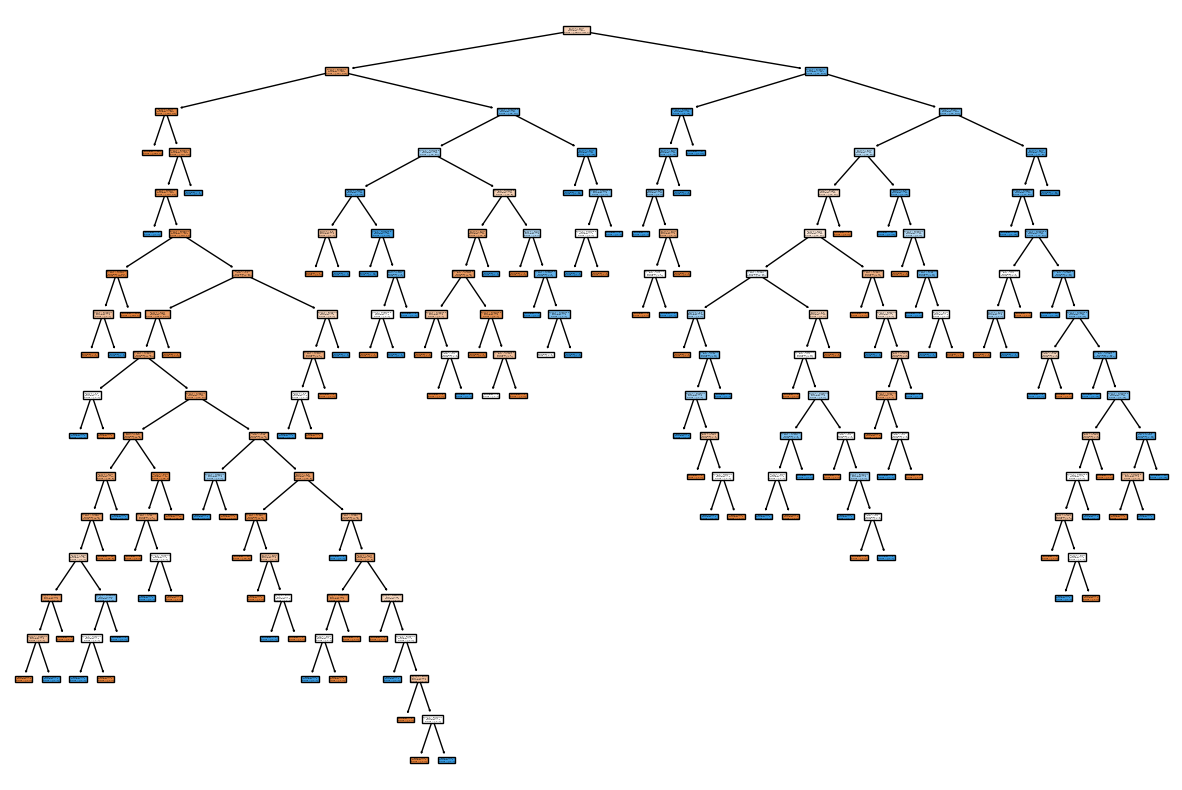

In [42]:
## Step 7: Visualize the Decision Tree (ONLY WITH DESCISION TREE)

plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)
plt.show()

In [48]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.91
